## Plotting the relationship between queue delay vs load

Presenting the results from changing the arrival rate (using dynamic batch with min, max: 1,8)

In [1]:
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import glob, os, re
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
print(pd.read_csv(fp, nrows=1).columns)

Index(['Request Rate', 'Inferences/Second', 'Client Send',
       'Network+Server Send/Recv', 'Server Queue', 'Server Compute Input',
       'Server Compute Infer', 'Server Compute Output', 'Client Recv',
       'p50 latency', 'p90 latency', 'p95 latency', 'p99 latency'],
      dtype='object')


In [34]:
files = sorted(glob.glob("test*.csv"))

rows = []
for fp in files:
    m = re.search(r"test(\d+)\.csv", os.path.basename(fp))
    if not m:
        continue
    request_rate = pd.read_csv(fp, nrows=1).iloc[0]["Request Rate"]
    q_usec = pd.read_csv(fp, nrows=1).iloc[0]["Server Queue"]  # μs
    rows.append((request_rate, q_usec / 1000.0))  # ms

,Request Rate,queue_ms
0,20.0,2.988
1,50.0,6.412
2,60.0,7.345
3,70.0,8.014
4,80.0,8.493
5,90.0,8.531
6,100.0,10.607
7,110.0,9.925
8,120.0,9.791
9,130.0,14.132


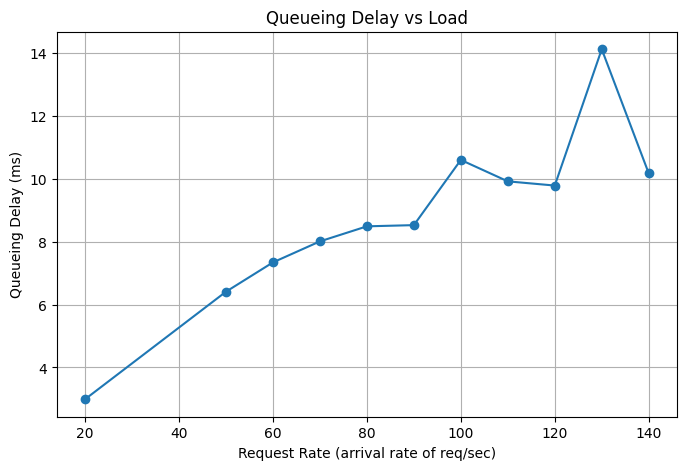

In [35]:
df = pd.DataFrame(rows, columns=["Request Rate", "queue_ms"]).sort_values("Request Rate").reset_index(drop=True)
display(df)

plt.figure(figsize=(8,5))
plt.plot(df["Request Rate"], df["queue_ms"], marker="o")
plt.xlabel("Request Rate (arrival rate of req/sec)")
plt.ylabel("Queueing Delay (ms)")
plt.title("Queueing Delay vs Load")
plt.grid(True)
plt.show()

In [36]:
#theory queue time
service_rate = 1/(17.3e-3)
rho_values = df["Request Rate"]/service_rate


In [40]:
theory_q_time = []
for rho in rho_values:
    val = (rho * 17.3e-3) / (2 * (1 - rho))
    theory_q_time.append(val)


In [41]:
theory_q_time

[0.0045762996941896015,
 0.05542407407407406,
 -0.23628157894736818,
 -0.04964526066350714,
 -0.03117604166666667,
 -0.024179622980251347,
 -0.02049931506849315,
 -0.01822918050941307,
 -0.016689033457249067,
 -0.015575540432345877,
 -0.01473298171589311]

In [42]:
rho_values

0     0.346
1     0.865
2     1.038
3     1.211
4     1.384
5     1.557
6     1.730
7     1.903
8     2.076
9     2.249
10    2.422
Name: Request Rate, dtype: float64